# TESS Exoplanet XGBoost Prototype

Prototype for Bharatiya Antariksh Hackathon 2026 Challenge 7:
**AI-enabled Detection of Exoplanets from Noisy Astronomical Light Curves**.

This notebook is intentionally small and Kaggle-friendly. It:

- reads drag-and-drop TESS light curves from `/kaggle/input`
- supports SPOC-style FITS files and simple CSV light curves
- optionally merges compact TIC/xCTL metadata by TIC ID
- extracts simple transit-inspired statistics, including Box Least Squares features
- trains an XGBoost binary classifier
- writes `tess_xgboost_predictions.csv`

Expected optional label file:

```text
tic_id,label
123456789,1
987654321,0
```

You can also use `file_name,label`. Positive labels can be `1`, `planet`,
`candidate`, `confirmed`, or `toi`; negative labels can be `0`,
`false_positive`, `eclipsing_binary`, `noise`, or `systematic`.

If no real data is attached, the notebook trains on a synthetic mini dataset so
that the full pipeline runs immediately.



## 1. Install and Import



In [1]:
import importlib.util
import subprocess
import sys


def ensure_package(package_name, import_name=None):
    """Install a package only if it is missing."""
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package_name]
        )


ensure_package("xgboost")
ensure_package("astropy")



In [2]:
from pathlib import Path
import math
import re
import warnings

import numpy as np
import pandas as pd

from IPython.display import display
from astropy.io import fits
from astropy.timeseries import BoxLeastSquares
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show_plot():
    if matplotlib.get_backend().lower() == "agg":
        plt.close()
    else:
        plt.show()


warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 120)



## 2. Configuration



In [3]:
RANDOM_SEED = 42

KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

DATA_ROOTS = [KAGGLE_INPUT] if KAGGLE_INPUT.exists() else [Path(".")]
OUTPUT_DIR = KAGGLE_WORKING if KAGGLE_WORKING.exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Keep the first run light. Raise these once the pipeline works.
MAX_LIGHT_CURVES = 250
MAX_CSV_LIGHT_CURVE_ROWS = 200_000
MAX_BLS_POINTS = 2_500

# Optional catalog merge. This is meant for compact TIC/xCTL extracts. Full TIC
# declination CSVs can be many GB, so the reader scans in chunks and stops early.
USE_TIC_CTL_METADATA = True
MAX_METADATA_CHUNKS = 30
METADATA_CHUNKSIZE = 200_000

np.random.seed(RANDOM_SEED)

print("Input roots:", [str(p) for p in DATA_ROOTS])
print("Output directory:", OUTPUT_DIR)



Input roots: ['.']
Output directory: outputs


## 3. Helpers for Labels, IDs, and Files



In [4]:
POSITIVE_WORDS = {
    "1",
    "true",
    "yes",
    "positive",
    "planet",
    "planet_candidate",
    "candidate",
    "confirmed",
    "toi",
    "pc",
    "transit",
}

NEGATIVE_WORDS = {
    "0",
    "false",
    "no",
    "negative",
    "nonplanet",
    "non_planet",
    "false_positive",
    "fp",
    "eb",
    "eclipsing",
    "eclipsing_binary",
    "binary",
    "noise",
    "systematic",
    "artifact",
    "star",
}


def normalize_column_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def normalize_tic(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    text = str(value).strip()
    if not text:
        return None
    text = re.sub(r"^tic\s*", "", text, flags=re.IGNORECASE)
    text = text.split(".")[0]
    match = re.search(r"\d+", text)
    if not match:
        return None
    return str(int(match.group(0)))


def tic_from_text(text):
    text = str(text)
    match = re.search(r"(?:tic|TIC)[_\-\s]*(\d+)", text)
    if match:
        return normalize_tic(match.group(1))

    # Common SPOC light curve pattern:
    # tessYYYY...-s0001-0000000123456789-xxxx-s_lc.fits
    match = re.search(r"-0*(\d{5,16})-", text)
    if match:
        return normalize_tic(match.group(1))
    return None


def standardize_label(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None

    if isinstance(value, (int, np.integer)):
        return int(value > 0)
    if isinstance(value, (float, np.floating)):
        if np.isnan(value):
            return None
        return int(value > 0.5)

    text = normalize_column_name(value)
    if text in NEGATIVE_WORDS:
        return 0
    if text in POSITIVE_WORDS:
        return 1
    if "false_positive" in text or "eclipsing" in text or "systematic" in text:
        return 0
    if "planet" in text or "candidate" in text or "confirmed" in text:
        return 1
    return None


def is_fits_file(path):
    name = path.name.lower()
    return name.endswith((".fits", ".fit", ".fits.gz", ".fit.gz", ".fz"))


def is_table_file(path):
    name = path.name.lower()
    return name.endswith((".csv", ".csv.gz", ".tsv", ".txt", ".dat"))


def looks_like_label_name(path):
    name = path.name.lower()
    return any(
        token in name
        for token in (
            "label",
            "labels",
            "train",
            "training",
            "target",
            "disposition",
        )
    )


def label_from_folder(path):
    parts = [normalize_column_name(part) for part in Path(path).parts]
    for part in reversed(parts):
        if part in POSITIVE_WORDS:
            return 1
        if part in NEGATIVE_WORDS:
            return 0
    return None



## 4. Read TESS Light Curves



In [5]:
TIME_COLUMNS = ["time", "btjd", "bjd", "jd", "mjd", "cadenceno", "cadence"]
FLUX_COLUMNS = [
    "pdcsap_flux",
    "sap_flux",
    "kspsap_flux",
    "flux",
    "flux_norm",
    "normalized_flux",
    "relative_flux",
    "pdc_flux",
]


def read_fits_light_curve(path):
    try:
        with fits.open(path, memmap=False) as hdul:
            tic_id = None
            for hdu in hdul:
                for key in ("TICID", "TIC_ID", "TIC", "TARGETID"):
                    if key in hdu.header:
                        tic_id = normalize_tic(hdu.header.get(key))
                        break
                if tic_id:
                    break

            if tic_id is None:
                tic_id = tic_from_text(path.name)

            for hdu in hdul:
                data = getattr(hdu, "data", None)
                names = getattr(data, "names", None)
                if not names:
                    continue
                columns = {normalize_column_name(name): name for name in names}
                time_col = next((columns[c] for c in TIME_COLUMNS if c in columns), None)
                flux_col = next((columns[c] for c in FLUX_COLUMNS if c in columns), None)
                if time_col is None or flux_col is None:
                    continue

                time = np.asarray(data[time_col], dtype=float)
                flux = np.asarray(data[flux_col], dtype=float)

                quality_col = columns.get("quality")
                if quality_col is not None:
                    quality = np.asarray(data[quality_col])
                    good_quality = quality == 0
                    if good_quality.sum() >= 50:
                        time = time[good_quality]
                        flux = flux[good_quality]

                return {
                    "tic_id": tic_id,
                    "file_name": path.name,
                    "path": str(path),
                    "time": time,
                    "flux": flux,
                    "label": label_from_folder(path),
                }
    except Exception as exc:
        print(f"Skipping FITS {path.name}: {exc}")
    return None


def sniff_table_columns(path):
    sep = "\t" if path.name.lower().endswith(".tsv") else None
    try:
        sample = pd.read_csv(path, sep=sep, engine="python", nrows=5)
    except Exception:
        return None, None, None
    columns = {normalize_column_name(col): col for col in sample.columns}
    time_col = next((columns[c] for c in TIME_COLUMNS if c in columns), None)
    flux_col = next((columns[c] for c in FLUX_COLUMNS if c in columns), None)
    tic_col = next(
        (
            columns[c]
            for c in ("tic_id", "ticid", "tic", "targetid", "target_id", "id")
            if c in columns
        ),
        None,
    )
    return time_col, flux_col, tic_col


def read_csv_light_curve(path):
    time_col, flux_col, tic_col = sniff_table_columns(path)
    if time_col is None or flux_col is None:
        return None

    sep = "\t" if path.name.lower().endswith(".tsv") else None
    try:
        usecols = [time_col, flux_col] + ([tic_col] if tic_col else [])
        df = pd.read_csv(
            path,
            sep=sep,
            engine="python",
            usecols=list(dict.fromkeys(usecols)),
            nrows=MAX_CSV_LIGHT_CURVE_ROWS,
        )
    except Exception as exc:
        print(f"Skipping table {path.name}: {exc}")
        return None

    tic_id = tic_from_text(path.name)
    if tic_id is None and tic_col and tic_col in df.columns and len(df):
        tic_id = normalize_tic(df[tic_col].iloc[0])

    return {
        "tic_id": tic_id,
        "file_name": path.name,
        "path": str(path),
        "time": df[time_col].to_numpy(dtype=float),
        "flux": df[flux_col].to_numpy(dtype=float),
        "label": label_from_folder(path),
    }


def discover_light_curves(roots):
    curves = []
    searched = 0
    for root in roots:
        if not root.exists():
            continue
        for path in root.rglob("*"):
            if not path.is_file():
                continue
            searched += 1
            curve = None
            if is_fits_file(path):
                curve = read_fits_light_curve(path)
            elif is_table_file(path) and not looks_like_label_name(path):
                curve = read_csv_light_curve(path)

            if curve is not None and len(curve["time"]) >= 50:
                curves.append(curve)
                if len(curves) >= MAX_LIGHT_CURVES:
                    break
        if len(curves) >= MAX_LIGHT_CURVES:
            break
    print(f"Searched {searched} files; found {len(curves)} usable light curves.")
    return curves


curves = discover_light_curves(DATA_ROOTS)



Searched 59 files; found 0 usable light curves.


## 4.1 Preview a Few Raw Light-Curve Rows

This is the "sanity-check" view: before training, look at a few raw rows from
the first TESS files the notebook found.



In [6]:
def preview_curve_rows(curves, n_curves=3, n_rows=12):
    if not curves:
        print("No light curves found yet. Add FITS/CSV files under /kaggle/input.")
        return

    for curve in curves[:n_curves]:
        time = np.asarray(curve["time"], dtype=float)
        flux = np.asarray(curve["flux"], dtype=float)
        mask = np.isfinite(time) & np.isfinite(flux)
        time = time[mask]
        flux = flux[mask]
        order = np.argsort(time)
        time = time[order]
        flux = flux[order]

        preview = pd.DataFrame(
            {
                "tic_id": curve.get("tic_id"),
                "file_name": curve.get("file_name"),
                "row": np.arange(len(time)),
                "time": time,
                "flux": flux,
                "label_from_folder": curve.get("label"),
            }
        ).head(n_rows)

        print(f"\nPreview: {curve.get('file_name')} | TIC {curve.get('tic_id')}")
        display(preview)

        plot_n = min(len(time), 3000)
        plt.figure(figsize=(10, 3))
        plt.scatter(time[:plot_n], flux[:plot_n], s=3, alpha=0.55)
        plt.title(f"Raw light curve preview: {curve.get('file_name')}")
        plt.xlabel("Time")
        plt.ylabel("Flux")
        plt.tight_layout()
        show_plot()


preview_curve_rows(curves)



No light curves found yet. Add FITS/CSV files under /kaggle/input.


## 5. Load Optional Labels



In [7]:
def find_label_file(roots):
    candidates = []
    for root in roots:
        if not root.exists():
            continue
        for path in root.rglob("*"):
            if path.is_file() and is_table_file(path) and looks_like_label_name(path):
                candidates.append(path)

    exact_names = {
        "labels.csv",
        "label.csv",
        "train_labels.csv",
        "training_labels.csv",
        "targets.csv",
    }
    candidates = sorted(
        candidates,
        key=lambda p: (p.name.lower() not in exact_names, len(str(p)), p.name.lower()),
    )
    return candidates[0] if candidates else None


def load_labels(path):
    if path is None:
        return {}, {}
    print("Loading labels from:", path)
    df = pd.read_csv(path)
    original_columns = list(df.columns)
    df.columns = [normalize_column_name(c) for c in df.columns]

    label_col = next(
        (
            c
            for c in (
                "label",
                "target",
                "is_planet",
                "planet",
                "class",
                "disposition",
                "y",
            )
            if c in df.columns
        ),
        None,
    )
    if label_col is None:
        raise ValueError(f"No label column found in {path}. Columns: {original_columns}")

    tic_col = next(
        (
            c
            for c in ("tic_id", "ticid", "tic", "target_id", "targetid", "id")
            if c in df.columns
        ),
        None,
    )
    file_col = next(
        (c for c in ("file_name", "filename", "file", "path", "object_id") if c in df.columns),
        None,
    )

    df["label_clean"] = df[label_col].map(standardize_label)
    df = df.dropna(subset=["label_clean"]).copy()
    df["label_clean"] = df["label_clean"].astype(int)

    by_tic = {}
    by_file = {}

    if tic_col is not None:
        for tic, label in zip(df[tic_col], df["label_clean"]):
            tic = normalize_tic(tic)
            if tic:
                by_tic[tic] = int(label)

    if file_col is not None:
        for file_name, label in zip(df[file_col], df["label_clean"]):
            key = Path(str(file_name)).name.lower()
            by_file[key] = int(label)
            by_file[Path(key).stem.lower()] = int(label)

    print(f"Loaded {len(df)} labels: {df['label_clean'].value_counts().to_dict()}")
    return by_tic, by_file


label_path = find_label_file(DATA_ROOTS)
labels_by_tic, labels_by_file = load_labels(label_path)



## 6. Feature Extraction



In [8]:
def finite_sorted(time, flux):
    time = np.asarray(time, dtype=float)
    flux = np.asarray(flux, dtype=float)
    mask = np.isfinite(time) & np.isfinite(flux)
    time = time[mask]
    flux = flux[mask]
    order = np.argsort(time)
    return time[order], flux[order]


def robust_mad(values):
    values = np.asarray(values, dtype=float)
    med = np.nanmedian(values)
    return np.nanmedian(np.abs(values - med))


def flatten_light_curve(time, flux):
    time, flux = finite_sorted(time, flux)
    if len(time) < 50:
        return time, flux

    median_flux = np.nanmedian(flux)
    if not np.isfinite(median_flux) or abs(median_flux) < 1e-12:
        median_flux = 1.0
    flux = flux / median_flux

    n = len(flux)
    window = int(max(31, min(401, n // 20)))
    if window % 2 == 0:
        window += 1

    trend = (
        pd.Series(flux)
        .rolling(window=window, center=True, min_periods=max(5, window // 4))
        .median()
        .bfill()
        .ffill()
        .to_numpy(copy=True)
    )

    trend[~np.isfinite(trend)] = np.nanmedian(trend[np.isfinite(trend)])
    trend[np.abs(trend) < 1e-12] = 1.0

    flat = flux / trend
    low, high = np.nanpercentile(flat, [0.1, 99.9])
    flat = np.clip(flat, low, high)
    return time, flat


def autocorr(values, lag):
    values = np.asarray(values, dtype=float)
    if len(values) <= lag + 2:
        return np.nan
    x = values[:-lag]
    y = values[lag:]
    if np.nanstd(x) < 1e-12 or np.nanstd(y) < 1e-12:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def longest_true_run(mask):
    best = 0
    current = 0
    for item in mask:
        if item:
            current += 1
            best = max(best, current)
        else:
            current = 0
    return best


def bls_features(time, flux):
    default = {
        "bls_period": np.nan,
        "bls_power": np.nan,
        "bls_depth": np.nan,
        "bls_duration": np.nan,
        "bls_transit_snr": np.nan,
        "bls_in_transit_fraction": np.nan,
    }

    if len(time) < 80:
        return default

    time = np.asarray(time, dtype=float)
    flux = np.asarray(flux, dtype=float)
    span = float(np.nanmax(time) - np.nanmin(time))
    if span < 2:
        return default

    if len(time) > MAX_BLS_POINTS:
        idx = np.linspace(0, len(time) - 1, MAX_BLS_POINTS).astype(int)
        time = time[idx]
        flux = flux[idx]

    time = time - np.nanmin(time)
    y = flux - np.nanmedian(flux)

    min_period = 0.5
    max_period = min(20.0, span / 2.0)
    if max_period <= min_period:
        return default

    periods = np.linspace(min_period, max_period, 120)
    durations = np.array([0.05, 0.1, 0.2])
    durations = durations[durations < min_period / 2]
    if len(durations) == 0:
        return default

    try:
        model = BoxLeastSquares(time, y)
        result = model.power(periods, durations, objective="snr")
        best = int(np.nanargmax(result.power))

        period = float(result.period[best])
        duration = float(result.duration[best])
        transit_time = float(result.transit_time[best])
        power = float(result.power[best])
        depth = float(getattr(result, "depth", np.array([np.nan]))[best])

        phase = ((time - transit_time + 0.5 * period) % period) / period - 0.5
        in_transit = np.abs(phase) < max(duration / period / 2.0, 1e-4)
        if in_transit.sum() < 3 or (~in_transit).sum() < 3:
            transit_snr = np.nan
        else:
            in_med = np.nanmedian(y[in_transit])
            out_med = np.nanmedian(y[~in_transit])
            noise = robust_mad(y[~in_transit]) + 1e-12
            transit_snr = float((out_med - in_med) / noise * math.sqrt(in_transit.sum()))

        return {
            "bls_period": period,
            "bls_power": power,
            "bls_depth": depth,
            "bls_duration": duration,
            "bls_transit_snr": transit_snr,
            "bls_in_transit_fraction": float(np.mean(in_transit)),
        }
    except Exception:
        return default


def extract_features(time, flux):
    time, flux = flatten_light_curve(time, flux)
    if len(time) < 50:
        return None

    centered = flux - np.nanmedian(flux)
    q = np.nanpercentile(flux, [1, 5, 10, 25, 50, 75, 90, 95, 99])
    mad = robust_mad(centered)
    dip_mask = centered < (-3.0 * mad if mad > 0 else np.nanpercentile(centered, 5))

    features = {
        "n_points": float(len(flux)),
        "time_span": float(np.nanmax(time) - np.nanmin(time)),
        "cadence_median": float(np.nanmedian(np.diff(time))) if len(time) > 2 else np.nan,
        "flux_mean": float(np.nanmean(flux)),
        "flux_std": float(np.nanstd(flux)),
        "flux_mad": float(mad),
        "flux_skew": float(stats.skew(centered, nan_policy="omit")),
        "flux_kurtosis": float(stats.kurtosis(centered, nan_policy="omit")),
        "flux_q01": float(q[0]),
        "flux_q05": float(q[1]),
        "flux_q10": float(q[2]),
        "flux_q25": float(q[3]),
        "flux_q50": float(q[4]),
        "flux_q75": float(q[5]),
        "flux_q90": float(q[6]),
        "flux_q95": float(q[7]),
        "flux_q99": float(q[8]),
        "dip_depth_q01": float(1.0 - q[0]),
        "dip_depth_q05": float(1.0 - q[1]),
        "bright_spike_q99": float(q[8] - 1.0),
        "deep_dip_fraction": float(np.nanmean(dip_mask)),
        "deep_dip_count": float(np.nansum(dip_mask)),
        "longest_dip_run": float(longest_true_run(dip_mask)),
        "autocorr_1": autocorr(centered, 1),
        "autocorr_5": autocorr(centered, 5),
        "autocorr_20": autocorr(centered, 20),
    }
    features.update(bls_features(time, flux))
    return features


def curve_label(curve):
    if curve.get("label") is not None:
        return curve["label"]

    tic_id = curve.get("tic_id")
    if tic_id and tic_id in labels_by_tic:
        return labels_by_tic[tic_id]

    file_name = curve.get("file_name", "").lower()
    stem = Path(file_name).stem.lower()
    if file_name in labels_by_file:
        return labels_by_file[file_name]
    if stem in labels_by_file:
        return labels_by_file[stem]

    return None


def build_feature_table(curves):
    rows = []
    for i, curve in enumerate(curves, start=1):
        features = extract_features(curve["time"], curve["flux"])
        if features is None:
            continue
        features.update(
            {
                "tic_id": curve.get("tic_id"),
                "file_name": curve.get("file_name"),
                "path": curve.get("path"),
                "label": curve_label(curve),
                "source": "uploaded",
            }
        )
        rows.append(features)
        if i % 50 == 0:
            print(f"Extracted features for {i} curves ...")

    df = pd.DataFrame(rows)
    if "label" in df.columns:
        df["label"] = df["label"].map(standardize_label)
    return df


feature_df = build_feature_table(curves)
print("Feature table shape:", feature_df.shape)
display(feature_df.head())



Feature table shape: (0, 0)


""


## 7. Optional TIC/xCTL Metadata Merge

The STScI TIC/CTL downloads are catalogs, not light curves. This cell merges
catalog columns such as `Tmag`, `Teff`, `rad`, `mass`, and sky position if you
attach a compact TIC/xCTL CSV extract to Kaggle.



In [9]:
DESIRED_METADATA_COLUMNS = {
    "id",
    "tic",
    "ticid",
    "tic_id",
    "targetid",
    "target_id",
    "tmag",
    "teff",
    "rad",
    "mass",
    "logg",
    "rho",
    "d",
    "plx",
    "ra",
    "dec",
    "eclong",
    "eclat",
    "pmra",
    "pmdec",
    "priority",
}


def find_metadata_files(roots):
    files = []
    for root in roots:
        if not root.exists():
            continue
        for path in root.rglob("*"):
            name = path.name.lower()
            if not path.is_file() or not is_table_file(path):
                continue
            if looks_like_label_name(path):
                continue
            if any(token in name for token in ("xctl", "ctl", "tic", "metadata", "catalog")):
                files.append(path)
    return sorted(files, key=lambda p: (p.stat().st_size, str(p)))


def load_metadata_for_tics(roots, target_tics):
    target_tics = {normalize_tic(tic) for tic in target_tics if normalize_tic(tic)}
    if not target_tics:
        return pd.DataFrame()

    for path in find_metadata_files(roots):
        try:
            header = pd.read_csv(path, nrows=0).columns.tolist()
        except Exception:
            continue

        normalized = {normalize_column_name(c): c for c in header}
        tic_col_norm = next(
            (
                c
                for c in ("tic_id", "ticid", "tic", "target_id", "targetid", "id")
                if c in normalized
            ),
            None,
        )
        if tic_col_norm is None:
            continue

        usecols = [
            original
            for norm, original in normalized.items()
            if norm in DESIRED_METADATA_COLUMNS
        ]

        print("Scanning metadata:", path.name)
        matches = []
        for chunk_index, chunk in enumerate(
            pd.read_csv(path, usecols=usecols, chunksize=METADATA_CHUNKSIZE)
        ):
            chunk.columns = [normalize_column_name(c) for c in chunk.columns]
            tic_col = normalize_column_name(normalized[tic_col_norm])
            chunk["tic_id"] = chunk[tic_col].map(normalize_tic)
            hit = chunk[chunk["tic_id"].isin(target_tics)].copy()
            if len(hit):
                matches.append(hit)
            if chunk_index + 1 >= MAX_METADATA_CHUNKS:
                break

        if matches:
            metadata = pd.concat(matches, ignore_index=True).drop_duplicates("tic_id")
            print(f"Matched {len(metadata)} metadata rows from {path.name}")
            return metadata

    return pd.DataFrame()


if USE_TIC_CTL_METADATA and not feature_df.empty and "tic_id" in feature_df.columns:
    metadata_df = load_metadata_for_tics(DATA_ROOTS, feature_df["tic_id"].dropna())
    if not metadata_df.empty:
        before = feature_df.shape
        metadata_numeric = metadata_df.copy()
        for col in metadata_numeric.columns:
            if col != "tic_id":
                metadata_numeric[col] = pd.to_numeric(metadata_numeric[col], errors="coerce")
        feature_df = feature_df.merge(metadata_numeric, on="tic_id", how="left")
        print("Merged metadata:", before, "->", feature_df.shape)
    else:
        print("No matching TIC/xCTL metadata found.")



## 8. Synthetic Fallback Dataset

This keeps the notebook usable even before you attach real TESS files.
The synthetic data is only for wiring up the prototype; replace it with
labeled TESS examples before using the score for science or judging.



In [10]:
def simulate_light_curve(has_planet, n_points=500):
    time = np.sort(np.random.uniform(0, 27, n_points))
    trend = 1.0 + 0.0015 * np.sin(2 * np.pi * time / np.random.uniform(8, 18))
    noise = np.random.normal(0, np.random.uniform(0.0008, 0.003), n_points)
    flux = trend + noise

    if has_planet:
        period = np.random.uniform(1.2, 9.0)
        duration = np.random.uniform(0.05, 0.22)
        depth = np.random.uniform(0.004, 0.035)
        epoch = np.random.uniform(0, period)
        phase = ((time - epoch + 0.5 * period) % period) - 0.5 * period
        transit = np.abs(phase) < duration / 2
        ingress = np.abs(np.abs(phase) - duration / 2) < duration / 5
        flux[transit] -= depth
        flux[ingress] += depth * 0.25 * np.random.rand(ingress.sum())
    else:
        # A few negatives include stellar variability or random non-periodic dips.
        flux += np.random.uniform(0, 0.004) * np.sin(
            2 * np.pi * time / np.random.uniform(0.7, 4.5)
        )
        if np.random.rand() < 0.35:
            centers = np.random.uniform(0, 27, np.random.randint(1, 4))
            for center in centers:
                flux[np.abs(time - center) < np.random.uniform(0.03, 0.12)] -= np.random.uniform(
                    0.002, 0.018
                )

    return time, flux


def make_synthetic_feature_table(n_positive=50, n_negative=70):
    rows = []
    for idx in range(n_positive + n_negative):
        label = int(idx < n_positive)
        time, flux = simulate_light_curve(label)
        features = extract_features(time, flux)
        features.update(
            {
                "tic_id": f"synthetic_{idx:04d}",
                "file_name": f"synthetic_{idx:04d}.csv",
                "path": "",
                "label": label,
                "source": "synthetic",
            }
        )
        rows.append(features)
    return pd.DataFrame(rows)


has_usable_labels = (
    not feature_df.empty
    and "label" in feature_df.columns
    and feature_df["label"].dropna().nunique() == 2
)

if has_usable_labels:
    train_df = feature_df.dropna(subset=["label"]).copy()
    prediction_df = feature_df.copy()
    print("Training on uploaded labeled data.")
else:
    train_df = make_synthetic_feature_table()
    prediction_df = feature_df.copy() if not feature_df.empty else train_df.copy()
    if feature_df.empty:
        print("No uploaded light curves found. Training and scoring synthetic curves.")
    else:
        print("Uploaded curves do not have two-class labels.")
        print("Training on synthetic curves and scoring uploaded curves for demo only.")

print("Train shape:", train_df.shape)
print("Prediction shape:", prediction_df.shape)
display(train_df.head())



No uploaded light curves found. Training and scoring synthetic curves.
Train shape: (120, 37)
Prediction shape: (120, 37)


,n_points,time_span,cadence_median,flux_mean,flux_std,flux_mad,flux_skew,flux_kurtosis,flux_q01,flux_q05,flux_q10,flux_q25,flux_q50,flux_q75,flux_q90,flux_q95,flux_q99,dip_depth_q01,dip_depth_q05,bright_spike_q99,deep_dip_fraction,deep_dip_count,longest_dip_run,autocorr_1,autocorr_5,autocorr_20,bls_period,bls_power,bls_depth,bls_duration,bls_transit_snr,bls_in_transit_fraction,tic_id,file_name,path,label,source
0,500.0,26.673387,0.034908,0.999592,0.004389,0.001394,-5.084778,31.824399,0.971135,0.996614,0.997395,0.998588,1.0,1.001366,1.002851,1.003510,1.004772,0.028865,0.003386,0.004772,0.030,15.0,4.0,0.490897,0.012090,-0.060141,7.403768,0.083058,0.026532,0.2,67.682631,0.020,synthetic_0000,synthetic_0000.csv,,1,synthetic
1,500.0,26.850791,0.039071,0.999872,0.001911,0.001098,-0.771109,1.798035,0.993566,0.996499,0.997789,0.998899,1.0,1.001076,1.002104,1.002717,1.003790,0.006434,0.003501,0.003790,0.060,30.0,5.0,0.171509,-0.086308,-0.038867,5.170521,0.020584,0.006015,0.1,19.706171,0.024,synthetic_0001,synthetic_0001.csv,,1,synthetic
2,500.0,26.937526,0.036062,0.998563,0.007144,0.001930,-3.159792,10.121283,0.968169,0.976802,0.995920,0.997935,1.0,1.001769,1.003412,1.004082,1.005677,0.031831,0.023198,0.005677,0.066,33.0,10.0,0.656157,0.089343,-0.050393,5.840079,0.138226,0.028918,0.2,80.596720,0.048,synthetic_0002,synthetic_0002.csv,,1,synthetic
3,500.0,26.970416,0.037087,0.999462,0.003709,0.000614,-5.479690,30.816262,0.976354,0.998317,0.998798,0.999360,1.0,1.000591,1.001117,1.001377,1.002364,0.023646,0.001683,0.002364,0.042,21.0,3.0,0.453843,-0.030313,-0.017680,7.265403,0.055919,0.022967,0.1,94.457015,0.012,synthetic_0003,synthetic_0003.csv,,1,synthetic
4,500.0,26.878700,0.036275,0.998258,0.008095,0.001985,-2.844845,8.032681,0.966511,0.971809,0.995077,0.997797,1.0,1.001781,1.003573,1.005090,1.009147,0.033489,0.028191,0.009147,0.080,40.0,4.0,0.378725,-0.061808,-0.019242,3.000883,0.123229,0.030409,0.1,69.174009,0.034,synthetic_0004,synthetic_0004.csv,,1,synthetic


## 9. Train XGBoost



In [11]:
ID_COLUMNS = {"tic_id", "file_name", "path", "source", "label"}


def numeric_feature_columns(df):
    numeric_cols = []
    for col in df.columns:
        if col in ID_COLUMNS:
            continue
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().any():
            numeric_cols.append(col)
            df[col] = converted
    return numeric_cols


feature_columns = numeric_feature_columns(train_df)
for col in feature_columns:
    if col not in prediction_df.columns:
        prediction_df[col] = np.nan
    prediction_df[col] = pd.to_numeric(prediction_df[col], errors="coerce")

X = train_df[feature_columns].replace([np.inf, -np.inf], np.nan)
y = train_df["label"].astype(int)

print(f"Using {len(feature_columns)} numeric features")
print("Class balance:", y.value_counts().to_dict())

imputer = SimpleImputer(strategy="median")

can_split = len(train_df) >= 20 and y.nunique() == 2 and y.value_counts().min() >= 2
if can_split:
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=RANDOM_SEED,
        stratify=y,
    )
else:
    X_train, X_valid, y_train, y_valid = X, None, y, None

X_train_imp = imputer.fit_transform(X_train)
scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

model = XGBClassifier(
    n_estimators=250,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    scale_pos_weight=scale_pos_weight,
    n_jobs=2,
)

model.fit(X_train_imp, y_train)
print("Model trained.")



Using 32 numeric features
Class balance: {0: 70, 1: 50}
Model trained.


## 10. Validate



              precision    recall  f1-score   support

           0      1.000     0.944     0.971        18
           1      0.923     1.000     0.960        12

    accuracy                          0.967        30
   macro avg      0.962     0.972     0.966        30
weighted avg      0.969     0.967     0.967        30

ROC AUC: 0.9907


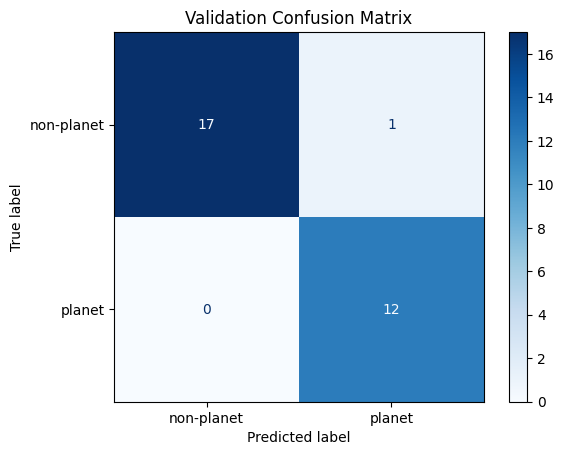

,importance
bls_transit_snr,0.206031
flux_skew,0.171905
flux_kurtosis,0.066731
flux_mean,0.047837
bls_depth,0.042475
bls_power,0.034034
autocorr_5,0.032429
bls_period,0.030458
autocorr_1,0.030328
deep_dip_fraction,0.030291


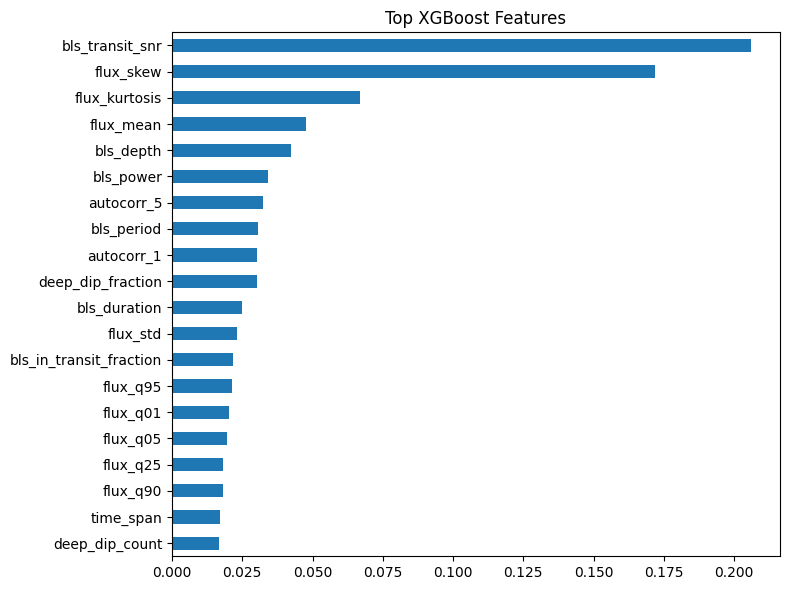

In [12]:
if X_valid is not None:
    X_valid_imp = imputer.transform(X_valid)
    valid_proba = model.predict_proba(X_valid_imp)[:, 1]
    valid_pred = (valid_proba >= 0.5).astype(int)

    print(classification_report(y_valid, valid_pred, digits=3))
    if y_valid.nunique() == 2:
        print("ROC AUC:", round(roc_auc_score(y_valid, valid_proba), 4))

    cm = confusion_matrix(y_valid, valid_pred)
    ConfusionMatrixDisplay(cm, display_labels=["non-planet", "planet"]).plot(
        cmap="Blues", values_format="d"
    )
    plt.title("Validation Confusion Matrix")
    show_plot()
else:
    print("Not enough labeled rows for a holdout split. Trained on all available rows.")

importance = (
    pd.Series(model.feature_importances_, index=feature_columns)
    .sort_values(ascending=False)
    .head(20)
)
display(importance.to_frame("importance"))

importance.sort_values().plot(kind="barh", figsize=(8, 6), title="Top XGBoost Features")
plt.tight_layout()
show_plot()



## 11. Score Curves and Save Output



In [13]:
score_X = prediction_df[feature_columns].replace([np.inf, -np.inf], np.nan)
score_proba = model.predict_proba(imputer.transform(score_X))[:, 1]

output = prediction_df[["tic_id", "file_name", "source"]].copy()
output["exoplanet_score"] = score_proba
output["predicted_label"] = (output["exoplanet_score"] >= 0.5).astype(int)
output = output.sort_values("exoplanet_score", ascending=False)

prediction_path = OUTPUT_DIR / "tess_xgboost_predictions.csv"
output.to_csv(prediction_path, index=False)

print("Saved predictions to:", prediction_path)
display(output.head(20))



Saved predictions to: outputs\tess_xgboost_predictions.csv


,tic_id,file_name,source,exoplanet_score,predicted_label
44,synthetic_0044,synthetic_0044.csv,synthetic,0.995403,1
22,synthetic_0022,synthetic_0022.csv,synthetic,0.994528,1
26,synthetic_0026,synthetic_0026.csv,synthetic,0.993882,1
34,synthetic_0034,synthetic_0034.csv,synthetic,0.993731,1
29,synthetic_0029,synthetic_0029.csv,synthetic,0.993716,1
39,synthetic_0039,synthetic_0039.csv,synthetic,0.993205,1
48,synthetic_0048,synthetic_0048.csv,synthetic,0.992603,1
31,synthetic_0031,synthetic_0031.csv,synthetic,0.992436,1
30,synthetic_0030,synthetic_0030.csv,synthetic,0.992254,1
45,synthetic_0045,synthetic_0045.csv,synthetic,0.991690,1


## 12. Quick Visual Check



In [14]:
def plot_curve(curve, title):
    time, flux = flatten_light_curve(curve["time"], curve["flux"])
    plt.figure(figsize=(10, 3))
    plt.scatter(time, flux, s=3, alpha=0.55)
    plt.axhline(1.0, color="black", lw=1, alpha=0.4)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Flattened relative flux")
    plt.tight_layout()
    show_plot()


if curves:
    best_names = set(output.head(3)["file_name"].str.lower())
    for curve in curves:
        if curve["file_name"].lower() in best_names:
            score = output.loc[
                output["file_name"] == curve["file_name"], "exoplanet_score"
            ].iloc[0]
            plot_curve(curve, f"{curve['file_name']} | score={score:.3f}")
else:
    print("No uploaded curves to plot. Add TESS FITS/CSV files to see real examples here.")



No uploaded curves to plot. Add TESS FITS/CSV files to see real examples here.


## 13. Save Reusable Model Artifact



In [15]:
import joblib

artifact = {
    "model": model,
    "imputer": imputer,
    "feature_columns": feature_columns,
    "notes": "Prototype XGBoost model for TESS light-curve exoplanet screening.",
}

model_path = OUTPUT_DIR / "tess_xgboost_model.joblib"
joblib.dump(artifact, model_path)
print("Saved model artifact to:", model_path)


Saved model artifact to: outputs\tess_xgboost_model.joblib
